# Importar

## Importar bibliotecas

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import sklearn
import pykrige
import seaborn as sns
from sklearn.model_selection import cross_val_score
from keras import Sequential, Input
from keras.optimizers import Adam
from keras.layers import Dense
import numpy as np

# Configuração Dos testes

In [2]:
# # Lista para armazenar os DataFrames
altitude = []

data_folder = "../data/"
# # Forma robusta e independente de OS
altitude.append(pd.read_csv(data_folder + 'Altitude_2025-10-14T20_07_43.980Z.csv'))
altitude.append(pd.read_csv(data_folder + 'Altitude_2025-10-14T20_15_03.183Z.csv'))
# altitude.append(pd.read_csv(data_folder + 'Boundaries_Tasca_WGS84_UTM22s_2025-10-14T20_15_36.71257Z.csv'))
# # Exibir o primeiro item
print(altitude[0])

              x          y  Altitude
0    -53.830763 -25.108393     670.4
1    -53.830764 -25.108394     670.3
2    -53.830764 -25.108394     670.2
3    -53.830765 -25.108394     670.1
4    -53.830765 -25.108394     670.1
...         ...        ...       ...
5125 -53.830846 -25.111721     637.0
5126 -53.830858 -25.111720     637.1
5127 -53.830866 -25.111720     637.0
5128 -53.830872 -25.111720     637.0
5129 -53.830874 -25.111721     637.2

[5130 rows x 3 columns]


In [3]:
data = altitude[1]
data

,x,y,Altitude
0,-53.829717,-25.109249,674.416
1,-53.830852,-25.108677,676.406
2,-53.831561,-25.108591,673.852
3,-53.831323,-25.108139,673.295
4,-53.831981,-25.108146,670.334
5,-53.832551,-25.107571,669.850
6,-53.833843,-25.107663,669.892
7,-53.833195,-25.107876,669.640
8,-53.832424,-25.108649,669.537
9,-53.831979,-25.109049,669.405


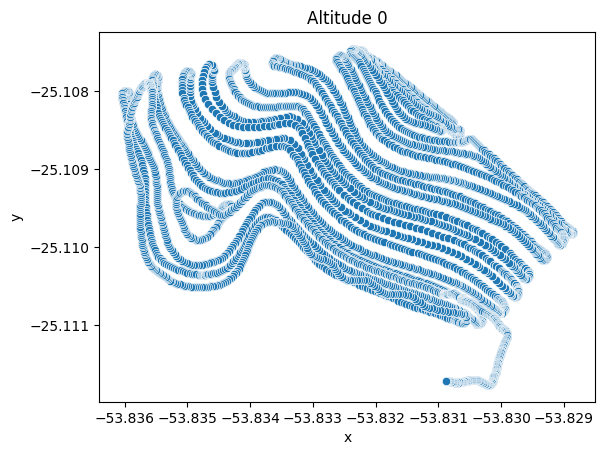

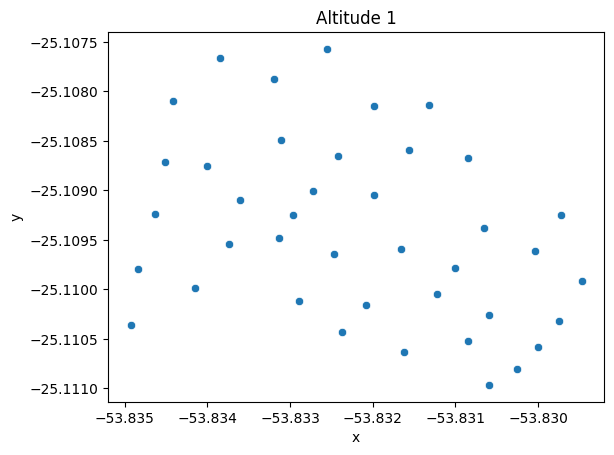

In [4]:
for index, data in enumerate(altitude):
  # print(data)
  plt.title(f"Altitude {index}")
  sns.scatterplot(data=data, x="x", y="y")
  plt.show()

# Treinamento dos modelos

In [5]:
modelos = {"krigagem": [], "RNA": []}

### Testes com krigagem

In [6]:
from pykrige.ok import OrdinaryKriging
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def krigering(data, variant='exponential'):
    # remover duplicados
    data_unique = data.groupby(["x", "y"], as_index=False).mean()

    x = data_unique["x"].astype(float)
    y = data_unique["y"].astype(float)
    z = data_unique["Altitude"].astype(float)

    # tamanho real da área (em graus)
    gridx = np.linspace(x.min(), x.max(), 80)
    gridy = np.linspace(y.min(), y.max(), 80)

    # converter range de metros → graus
    vrange = 304 / 111000  # ≈ 0.00274 graus

    OK = OrdinaryKriging(
        x=x,
        y=y,
        z=z,
        variogram_model=variant,  # fixo pq parametros são exponenciais
        variogram_parameters={"sill": 97.6, "range": vrange, "nugget": 0},
        enable_plotting=False
    )

    zz, ss = OK.execute("grid", gridx, gridy)
    modelos["krigagem"].append(OK)
    sns.heatmap(zz)
    plt.title(f"Krigagem ({variant})")
    plt.show()

    return zz, ss

### Testes de RNA

In [7]:
def rna(data: pd.DataFrame, number_intermediary_layers: list = None, activation='relu'):
  if number_intermediary_layers is None:
      number_intermediary_layers = [1] # Default value if none provided

  model = Sequential()
  model.add(Input(shape=(2,))) # Input layer

  if len(number_intermediary_layers) == 0:
    name = "sem layer"
  else:
    name = f"layer oculto: {number_intermediary_layers} - função: {activation}"
    # Iterate through the list of layer sizes to create hidden layers
    for layer_size in number_intermediary_layers:
      if layer_size <= 0:
          raise ValueError(f"Layer size must be a positive integer. Received: {layer_size}")
      model.add(Dense(layer_size, activation=activation)) # Use layer_size for units

  model.add(Dense(1, activation='linear')) # Output layer
  model.compile(optimizer='adam', loss='mse', metrics=['mae'])

  # --- Treinando ---
  x, z = data.iloc[:,:-1],data.iloc[:,-1]
  history = model.fit(x, z, epochs=1000, batch_size=32, validation_split=0.2, verbose=0)
  print(history)

  loss, mae = model.evaluate(x, z, verbose=0)
  print(name)
  modelos["RNA"].append(model)
  print(f"Erro médio absoluto: {mae:.4f} - Loss: {loss:.4f}")
  return model

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def create_grid(data: pd.DataFrame, resolution: float, model):
    """
    Gera previsões do `model` sobre um grid definido pelos pontos x,y em `data`.
    Retorna um DataFrame com colunas ['x','y','z'] e plota o heatmap.
    """
    # garante numpy arrays / colunas corretas
    x = data.iloc[:, 0].to_numpy()
    y = data.iloc[:, 1].to_numpy()
    min_x, max_x = x.min(), x.max()
    min_y, max_y = y.min(), y.max()

    # cria o grid com step = resolution (aceita floats)
    grid_x = np.arange(min_x, max_x + 1e-8, resolution)
    grid_y = np.arange(min_y, max_y + 1e-8, resolution)

    preds = []
    for xi in grid_x:
        # prepara um batch para acelerar várias predições (opcional)
        batch = np.column_stack([np.full(grid_y.shape, xi), grid_y])
        # previsões em batch: model.predict espera shape (N, features)
        y_pred = model.predict(batch)
        # y_pred pode ser (N,1) ou (N,), normaliza para 1D
        y_pred = np.asarray(y_pred).reshape(-1)
        for yi, zi in zip(grid_y, y_pred):
            preds.append([xi, yi, float(zi)])

    predict_df = pd.DataFrame(preds, columns=["x", "y", "z"])

    # pivot para matriz (y x x) e plot
    grid_data = predict_df.pivot(index="y", columns="x", values="z")
    plt.figure(figsize=(8, 6))
    sns.heatmap(grid_data, cmap="viridis")
    plt.title("Heatmap da previsão da RNA")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()

    return predict_df

# # ---------------------------
# # CHAMADA (exemplos, escolha o que combina com seu notebook)
# # ---------------------------

# # 1) Se sua tabela se chama `data` e o modelo `model`:
# # ajustei resolution para 0.1 como exemplo (mude para 10 se quiser passo maior)
# grid_df = create_grid(altitude[0], resolution=0.0001, model=model)

# # 2) Se você realmente tem uma lista/array `altitude` e o primeiro elemento é o DataFrame:
# # grid_df = create_grid(altitude[0], resolution=0.1, model=model)

# # 3) Se quiser imprimir/inspecionar as primeiras linhas:
# print(grid_df.head())


In [9]:
# for i in range(0,10):
#   for activation in ['relu', 'sigmoid', 'tanh', 'gelu']:
#     size = int(math.pow(2,i))
#     model = rna(altitude[0], size, activation)
#     create_grid(altitude[0], 0.0001, model)

In [10]:
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Input


def cross_validate_mlp(data: pd.DataFrame, n_splits=5, number_intermediary_layers: list = None, activation='relu'):
    x, z = data.iloc[:, :-1], data.iloc[:, 2]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mae_scores = []
    loss_scores = []

    if number_intermediary_layers is None:
        number_intermediary_layers = [] # Default to no hidden layers if not provided

    for train_index, test_index in kf.split(x):
        x_train, x_test = x.iloc[train_index], x.iloc[test_index]
        z_train, z_test = z.iloc[train_index], z.iloc[test_index]

        model = Sequential()
        model.add(Input(shape=(2,))) # Input layer

        if len(number_intermediary_layers) > 0:
            for layer_size in number_intermediary_layers:
                if layer_size <= 0:
                    raise ValueError(f"Layer size must be a positive integer. Received: {layer_size}")
                model.add(Dense(layer_size, activation=activation))

        model.add(Dense(1, activation='linear')) # Output layer
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        model.fit(x_train, z_train, epochs=1000, batch_size=32, verbose=0)

        loss, mae = model.evaluate(x_test, z_test, verbose=0)
        mae_scores.append(mae)
        loss_scores.append(loss)

    layer_description = "no hidden layers" if len(number_intermediary_layers) == 0 else f"{len(number_intermediary_layers)} hidden layers with sizes {number_intermediary_layers}"
    print(f"Model with {layer_description} and {activation} activation:")
    print(f"Average MAE: {np.mean(mae_scores):.4f} - Average Loss: {np.mean(loss_scores):.4f}")


## Teste De Altitude 0

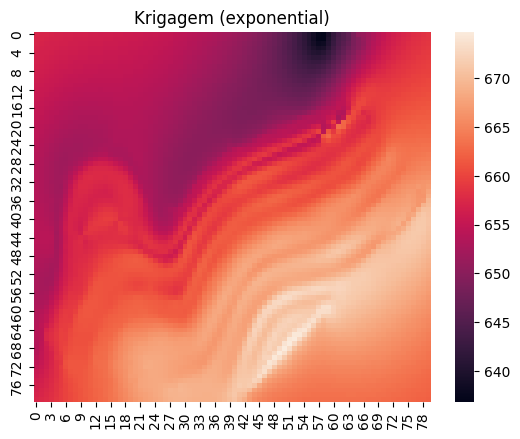

KeyboardInterrupt: 

In [11]:

def test_altitude(data):
  granularidade = 0.0005
  krigering(data, 'exponential')
  a = ['relu','tanh','sigmoid']
  # Case for no hidden layers (testing only 'relu' for brevity)
  for activation in a:
    model = rna(data=data, number_intermediary_layers=[], activation=activation) # Pass empty list for no hidden layers
    create_grid(data, granularidade, model)

  # Cases for single hidden layer with sizes from 1 to 2 (reduced range)
  for i in range(1,60): # Start from 1 for layer size, testing 1 and 2 layers
    for activation in a:
      model = rna(data=data, number_intermediary_layers=[i], activation=activation)
      create_grid(data, granularidade, model)

  # Cases for two hidden layers with sizes from 1 to 2 (reduced range)
  for i in range(1,60,2):
    for j in range(1,60,2):
      for activation in a:
        model = rna(data=data, number_intermediary_layers=[i, j], activation=activation)
        create_grid(data, granularidade, model)

  # Cases for three hidden layers with sizes from 1 to 2 (reduced range)
  for i in range(1,60,2):
    for j in range(1,60,2):
      for k in range(1,60,2):
        for activation in a:
          model = rna(data=data, number_intermediary_layers=[i, j, k], activation=activation)
          create_grid(data, 0.0001, model)
test_altitude(altitude[0])

## Teste De Altitude 1

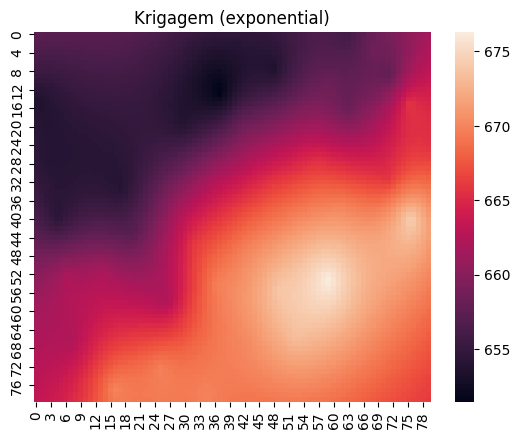

sem layer
Erro médio absoluto: 593.7799 - Loss: 352620.5312


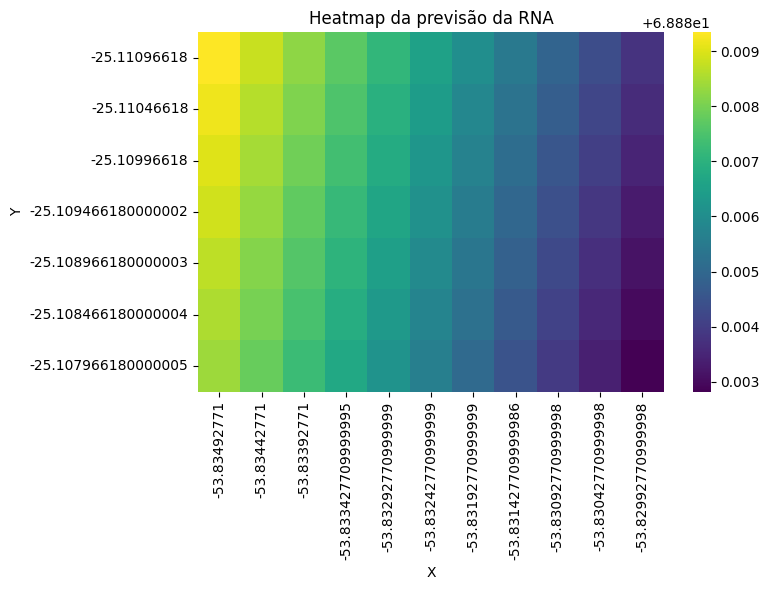

layer oculto: [1] - função: relu
Erro médio absoluto: 661.6660 - Loss: 437847.8438


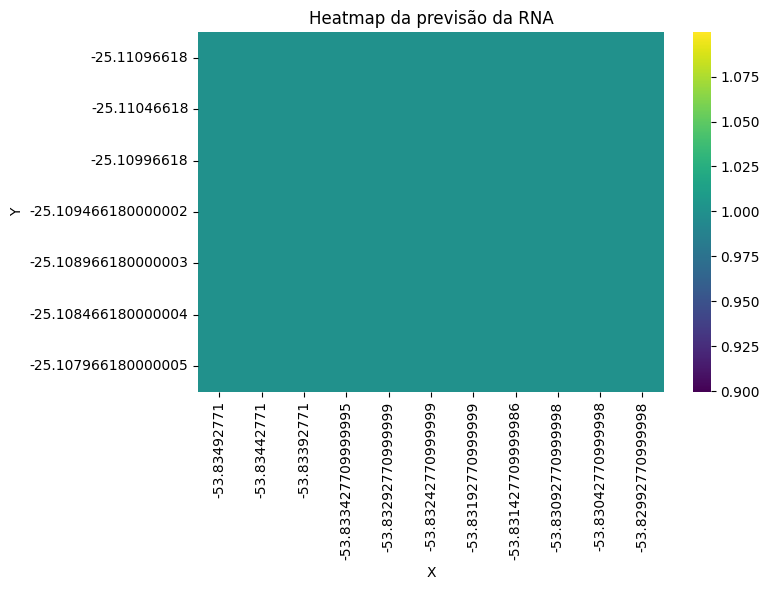

layer oculto: [2] - função: relu
Erro médio absoluto: 389.4367 - Loss: 151706.9688


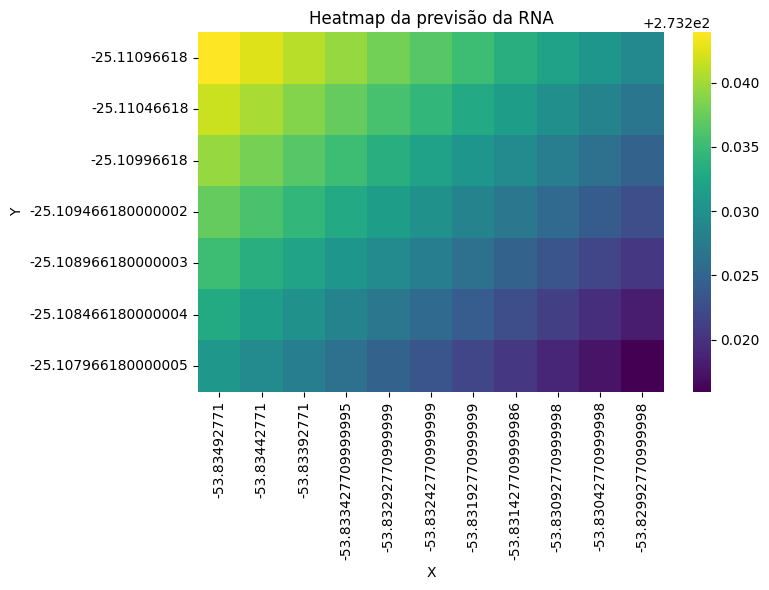

layer oculto: [1, 1] - função: relu
Erro médio absoluto: 661.6660 - Loss: 437847.8438


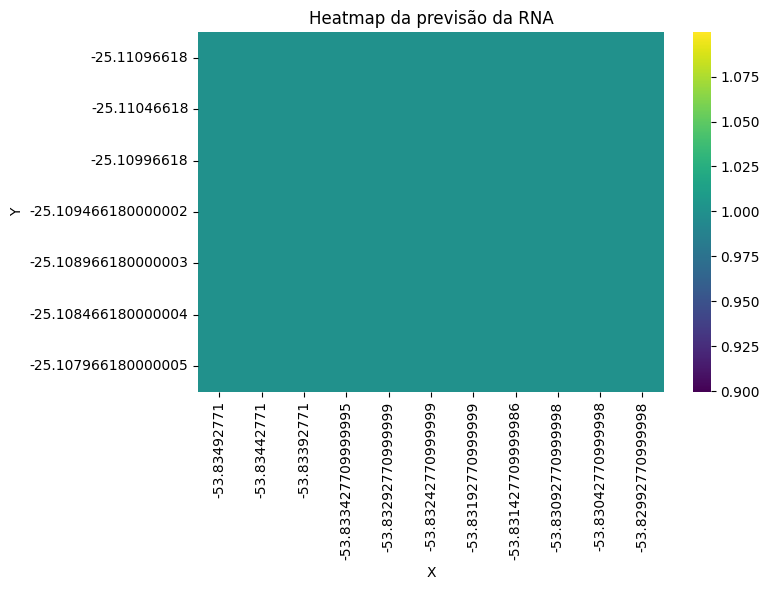

layer oculto: [1, 2] - função: relu
Erro médio absoluto: 661.6660 - Loss: 437847.8438


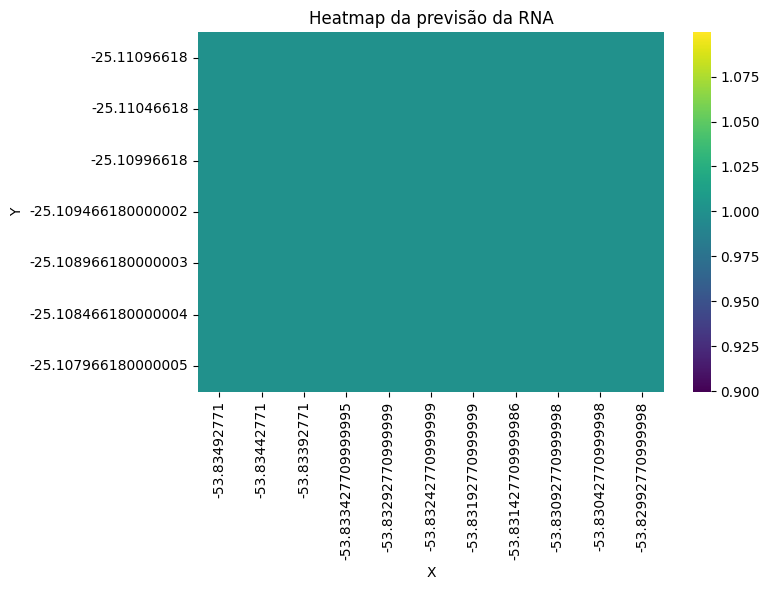

layer oculto: [2, 1] - função: relu
Erro médio absoluto: 661.6660 - Loss: 437847.8438


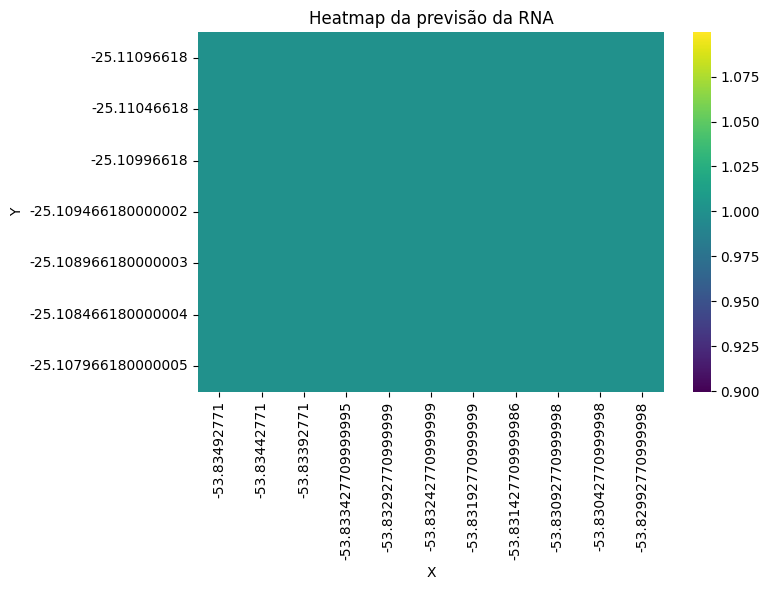

layer oculto: [2, 2] - função: relu
Erro médio absoluto: 661.6660 - Loss: 437847.8438


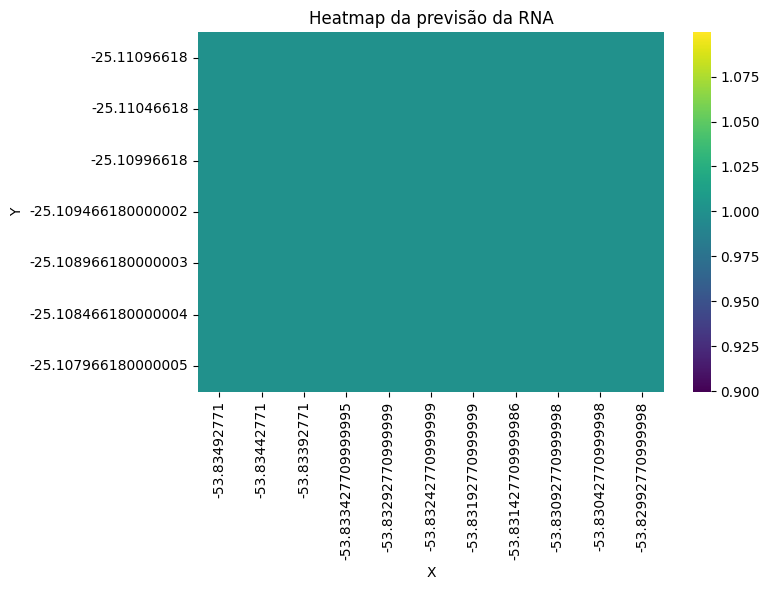

layer oculto: [1, 1, 1] - função: relu
Erro médio absoluto: 661.6660 - Loss: 437847.8438


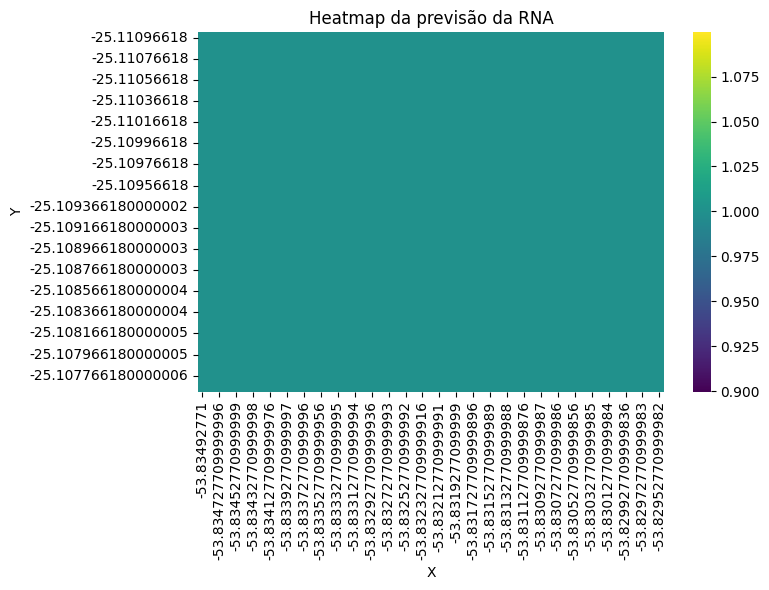

layer oculto: [1, 1, 2] - função: relu
Erro médio absoluto: 661.6660 - Loss: 437847.8438


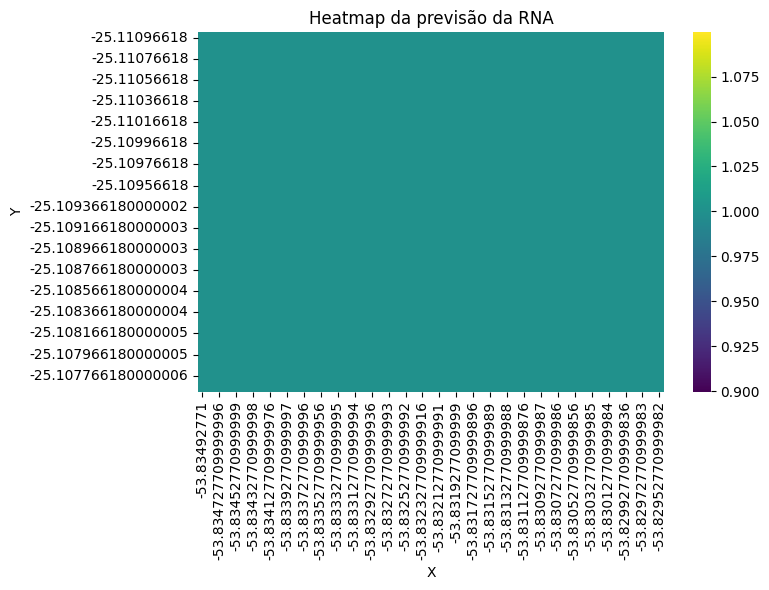

layer oculto: [1, 2, 1] - função: relu
Erro médio absoluto: 661.6660 - Loss: 437847.8438


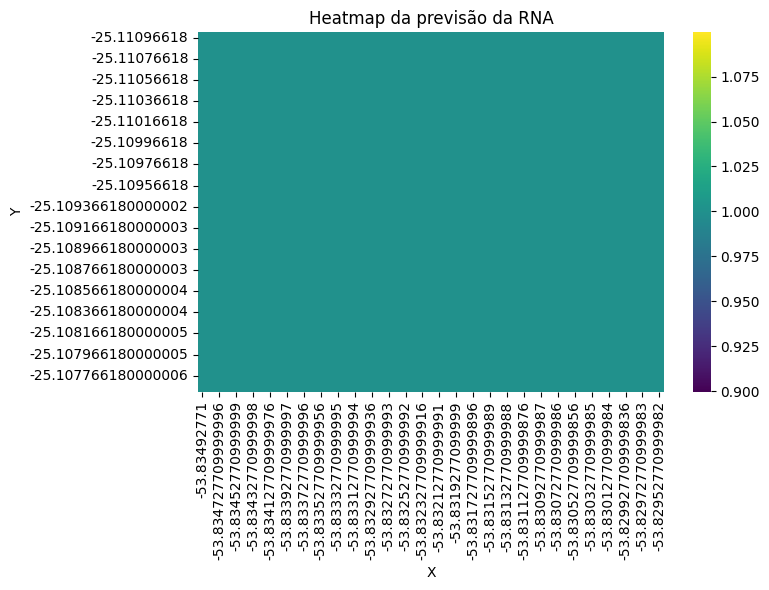

layer oculto: [1, 2, 2] - função: relu
Erro médio absoluto: 6.0966 - Loss: 50.5264


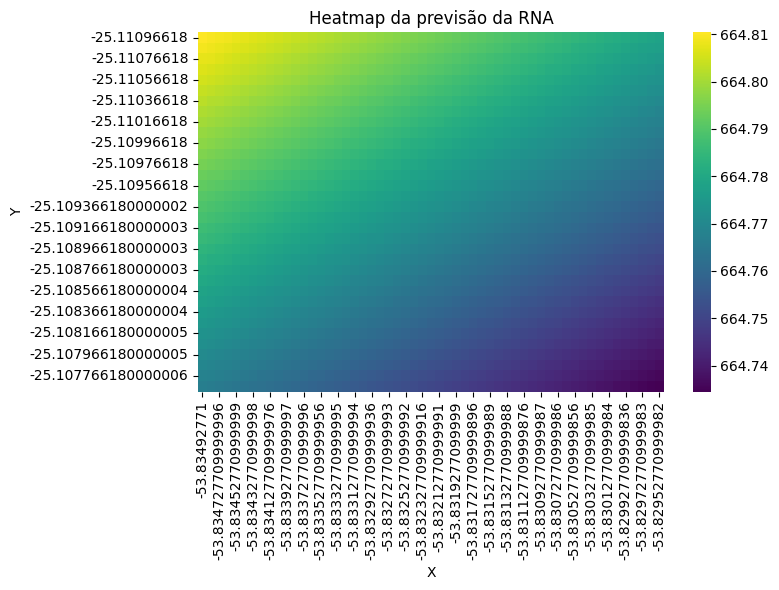

layer oculto: [2, 1, 1] - função: relu
Erro médio absoluto: 661.6670 - Loss: 437849.1562


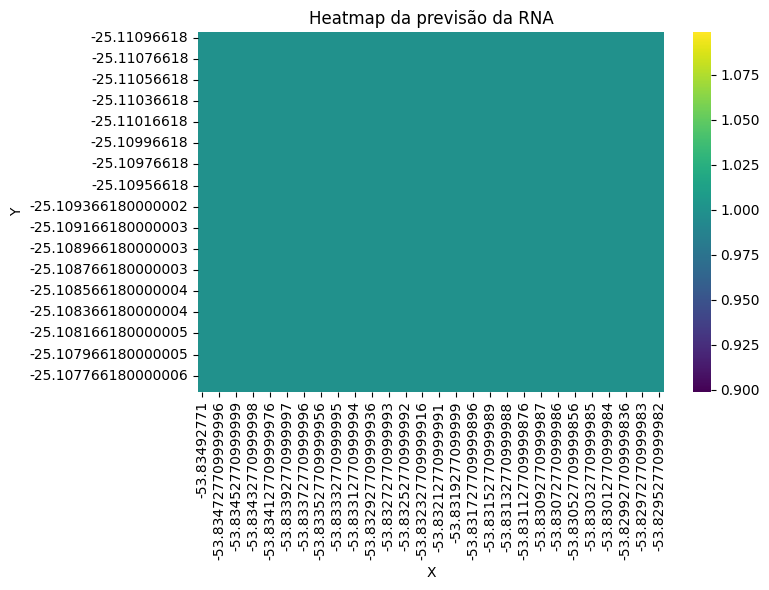

layer oculto: [2, 1, 2] - função: relu
Erro médio absoluto: 661.6660 - Loss: 437847.8438


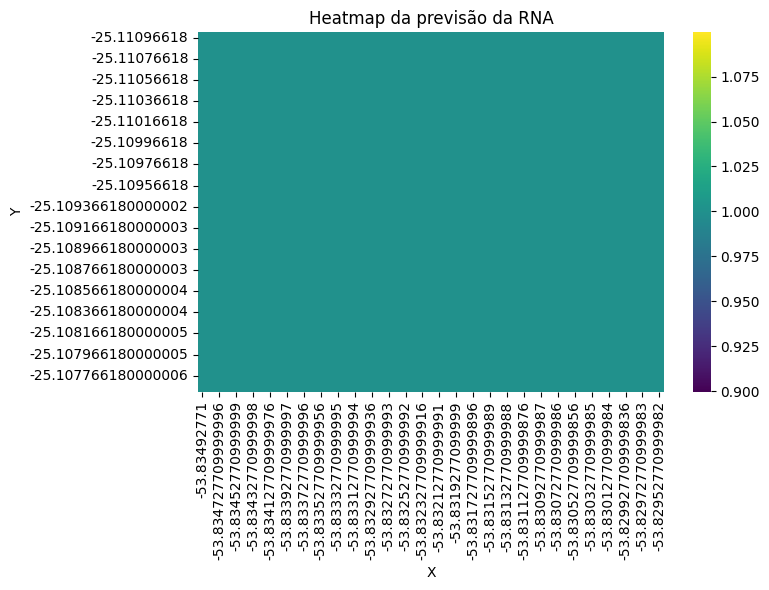

layer oculto: [2, 2, 1] - função: relu
Erro médio absoluto: 661.6660 - Loss: 437847.8438


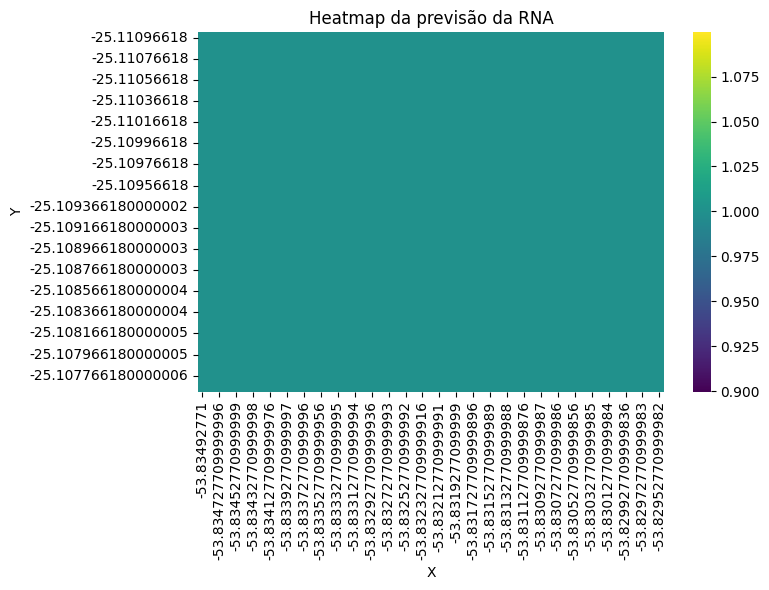

layer oculto: [2, 2, 2] - função: relu
Erro médio absoluto: 6.0892 - Loss: 50.3130


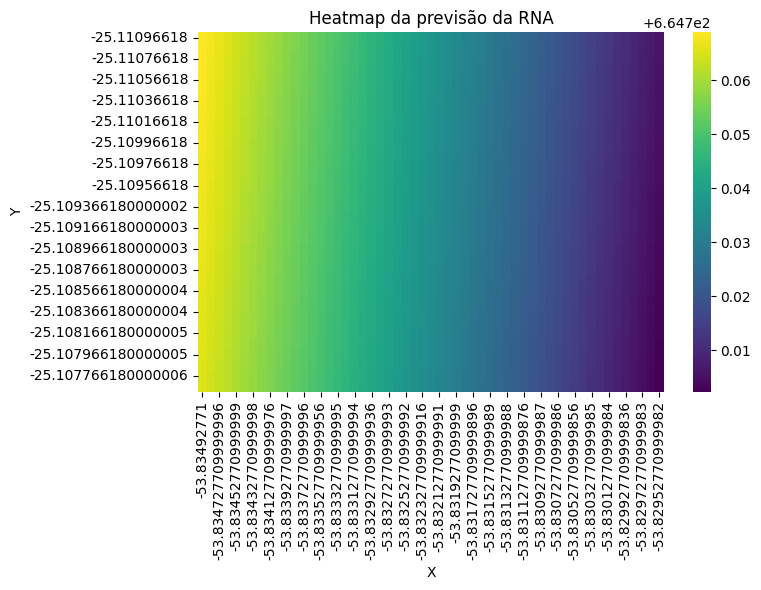

In [ ]:
test_altitude(altitude[1])

In [ ]:
test_altitude(altitude[2])

KeyError: 'Altitude'

In [ ]:
for i, model in enumerate(modelos["RNA"]):
    model.save(f'../models/rna{i}')

c:\Users\Erik\Projetos\IC-RNA-agricultura\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
c:\Users\Erik\Projetos\IC-RNA-agricultura\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
c:\Users\Erik\Projetos\IC-RNA-agricultura\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
c:\Users\Erik\Projetos\IC-RNA-agricultura\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
c:\Users\Erik\Projetos\IC-RNA-agricultura\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVR was fitted with featur

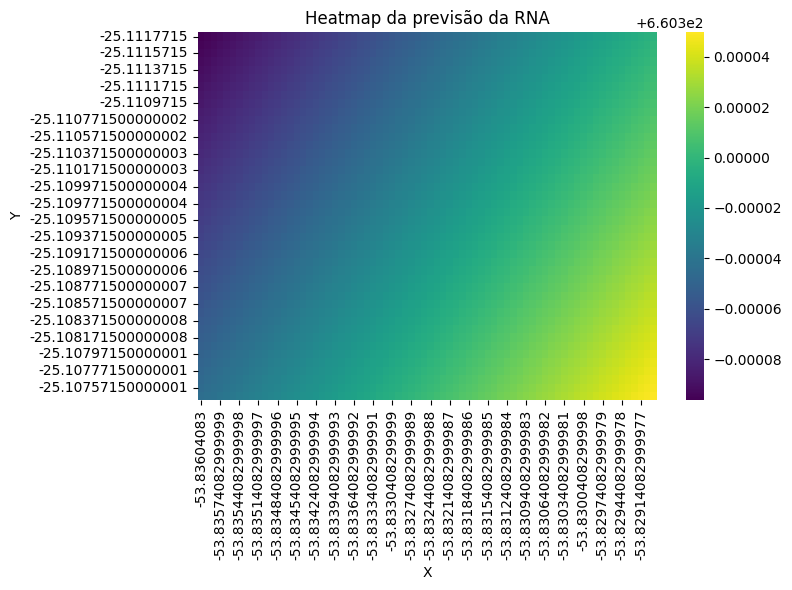

SVR Average MAE: 4.9907


In [17]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

def cross_validate_svr(data: pd.DataFrame, n_splits=5):
    x, z = data.iloc[:, :-1], data.iloc[:, 2]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mae_scores = []

    for train_index, test_index in kf.split(x):
        x_train, x_test = x.iloc[train_index], x.iloc[test_index]
        z_train, z_test = z.iloc[train_index], z.iloc[test_index]

        model = SVR(kernel='rbf')
        model.fit(x_train, z_train)

        z_pred = model.predict(x_test)
        mae = mean_absolute_error(z_test, z_pred)
        mae_scores.append(mae)
    model = SVR(kernel='rbf')
    model.fit(x, z)
    create_grid(data, 0.0001, model)

    print(f"SVR Average MAE: {np.mean(mae_scores):.4f}")
cross_validate_svr(altitude[0])